## Comparison across resolutions

In [1]:
%matplotlib inline
import time
import numpy as np
import xesmf as xe
import xarray as xr
import cmocean as cm
import cartopy.crs as ccrs
import matplotlib.ticker
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import matplotlib.gridspec as gridspec
from scipy.interpolate import RegularGridInterpolator

import os
import h5py
import scipy.io
from scipy.io import loadmat
from matplotlib.ticker import LogLocator, ScalarFormatter

In [2]:
# res = np.array([1.00, 0.90, 0.80, 0.75, 0.60, 0.50, 0.40, 0.25, 0.125])
res = np.array([1.00, 0.80, 0.75, 0.60, 0.50, 0.40, 0.30, 0.25, 0.125])

grid = 180/res
print(grid)

[ 180.  225.  240.  300.  360.  450.  600.  720. 1440.]


In [3]:
# old & new criteria, old & new without spring force
cd_scal = np.full((5,res.size),np.nan) 
op_scal = np.full((5,res.size),np.nan)
wd_scal = np.full((5,res.size),np.nan)
en_err = np.full((5,res.size),np.nan)
rmse = np.full((5,res.size),np.nan)
ener = np.full((5,res.size),np.nan)
frac = np.full((5,res.size),np.nan)
pe = np.full((5,res.size),np.nan)

In [4]:
pe1 = 1.52 #1.34
frac1 = 0.33 #0.321
ef1 = 2.47 #2.435

# frac1=0.321;
# ke1=2.26;
# pe1=1.55;
# ef1=2.434;

In [5]:
for i in range(res.size):
    print('i = ', i)
    print('res = ', res[i])
    fiM2_synbath = loadmat("/g/data/nm03/lxy581/matlab_model/data/combined_res%.3f_M2_3D_synbath_logk.mat"%res[i])
        
    # Example: read a dataset
    RMSE   = fiM2_synbath['RMSE66'][:]*100 # wd, op, cd 
    PE_net = fiM2_synbath['PE_net'][:]
    Fcoast = fiM2_synbath['Fcoast'][:]
    Fwave  = fiM2_synbath['Fwave'][:]
    # En_err = fiM2_synbath['En_err'][:]
    total  = fiM2_synbath['total'][:]
    parti  = fiM2_synbath['frac'][:]
    # En_err = 1/6*(PE_net-pe1)**2/pe1**2 + 4/6*(total-ef1)**2/ef1**2 + 1/6*(parti-frac1)**2/frac1**2
    En_err = 1/3*np.abs(PE_net-pe1)/pe1 + 1/3*np.abs(total-ef1)/ef1 + 1/3*np.abs(parti-frac1)/frac1
    
    k0array = np.squeeze(fiM2_synbath['k0array'][:])
    print('Check k0: ',k0array[0])
    wdarray = np.squeeze(fiM2_synbath['wdarray'][:])
    oparray = np.squeeze(fiM2_synbath['oparray'][:])
    lon = np.squeeze(fiM2_synbath['lon_out'][:])
    lat = np.squeeze(fiM2_synbath['lat_out'][:])

    # find minimum RMSE in open ocean (>1000m)
    m_val = np.nanmin(RMSE)                 # global min
    linearIndex = np.nanargmin(RMSE)        # linear index
    kk, jj, ii = np.unravel_index(linearIndex, RMSE.shape)  # convert to subscripts
    wd_scal[0,i] = wdarray[ii]
    op_scal[0,i] = oparray[jj]
    cd_scal[0,i] = k0array[kk] * np.sqrt(1000)
    en_err[0,i]  = En_err[kk,jj,ii]
    rmse[0,i]  = RMSE[kk,jj,ii]
    ener[0,i] = total[kk,jj,ii]
    frac[0,i]  = parti[kk,jj,ii]
    pe[0,i] = PE_net[kk,jj,ii]

    m_val_en = np.nanmin(En_err)
    linearIndex_en = np.nanargmin(En_err)
    kk_en, jj_en, ii_en = np.unravel_index(linearIndex_en, En_err.shape)
    wd_scal[1,i] = wdarray[ii_en]
    op_scal[1,i] = oparray[jj_en]
    cd_scal[1,i] = k0array[kk_en] * np.sqrt(1000)
    en_err[1,i] = En_err[kk_en,jj_en,ii_en]
    rmse[1,i]  = RMSE[kk_en,jj_en,ii_en]
    ener[1,i] = total[kk_en,jj_en,ii_en]
    frac[1,i]  = parti[kk_en,jj_en,ii_en]
    pe[1,i] = PE_net[kk_en,jj_en,ii_en]

    # find minimum RMSE in open ocean (>1000m)
    m_val = np.nanmin(RMSE[:,0,:])                 # global min
    linearIndex = np.nanargmin(RMSE[:,0,:])        # linear index
    kk, ii = np.unravel_index(linearIndex, RMSE[:,0,:].shape)  # convert to subscripts
    print('no out-of-phase: ',kk,ii)
    wd_scal[2,i] = wdarray[ii]
    op_scal[2,i] = oparray[0]
    cd_scal[2,i] = k0array[kk] * np.sqrt(1000)
    en_err[2,i] = En_err[kk,0,ii]
    rmse[2,i]  = RMSE[kk,0,ii]
    ener[2,i] = total[kk,0,ii]
    frac[2,i]  = parti[kk,0,ii]
    pe[2,i] = PE_net[kk,0,ii]

i =  0
res =  1.0
Check k0:  3.1622776601683796e-06
no out-of-phase:  40 26
i =  1
res =  0.8
Check k0:  3.1622776601683796e-06
no out-of-phase:  55 29
i =  2
res =  0.75
Check k0:  3.1622776601683796e-06
no out-of-phase:  44 27
i =  3
res =  0.6
Check k0:  3.1622776601683796e-06
no out-of-phase:  54 24
i =  4
res =  0.5
Check k0:  3.1622776601683796e-06
no out-of-phase:  53 22
i =  5
res =  0.4
Check k0:  3.1622776601683796e-06
no out-of-phase:  45 11
i =  6
res =  0.3
Check k0:  3.1622776601683796e-06
no out-of-phase:  40 10
i =  7
res =  0.25
Check k0:  3.1622776601683796e-06
no out-of-phase:  36 9
i =  8
res =  0.125
Check k0:  3.1622776601683796e-06
no out-of-phase:  14 6


In [6]:
test_num = 5
print(np.linspace(test_num-1, test_num+1, 3))

[4. 5. 6.]


In [7]:
for i in range(res.size):
# for i in range(5,6):
    print('i = ', i)
    print('res[i] = ',res[i])
    fiM2_synbath = loadmat("/g/data/nm03/lxy581/matlab_model/data/combined_res%.3f_M2_3D_synbath_logk.mat"%res[i])
        
    # Example: read a dataset
    RMSE   = fiM2_synbath['RMSE66'][:]*100 # wd, op, cd 
    PE_net = fiM2_synbath['PE_net'][:]
    Fcoast = fiM2_synbath['Fcoast'][:]
    Fwave  = fiM2_synbath['Fwave'][:]
    # En_err = fiM2_synbath['En_err'][:]
    total  = fiM2_synbath['total'][:]
    parti  = fiM2_synbath['frac'][:]
    # En_err = 1/6*(PE_net-pe1)**2/pe1**2 + 4/6*(total-ef1)**2/ef1**2 + 1/6*(parti-frac1)**2/frac1**2
    En_err = 1/3*np.abs(PE_net-pe1)/pe1 + 1/3*np.abs(total-ef1)/ef1 + 1/3*np.abs(parti-frac1)/frac1
    
    k0array = np.squeeze(fiM2_synbath['k0array'][:])
    # print('cd min max: ',np.nanmin(k0array)*np.sqrt(1000),np.nanmax(k0array)*np.sqrt(1000))
    wdarray = np.squeeze(fiM2_synbath['wdarray'][:])
    oparray = np.squeeze(fiM2_synbath['oparray'][:])
    lon = np.squeeze(fiM2_synbath['lon_out'][:])
    lat = np.squeeze(fiM2_synbath['lat_out'][:])

    linearIndex_en = np.nanargmin(En_err)
    kk_en, jj_en, ii_en = np.unravel_index(linearIndex_en, En_err.shape)
    print(kk_en,jj_en,ii_en)
    wd_scal[1,i] = wdarray[ii_en]
    op_scal[1,i] = oparray[jj_en]
    cd_scal[1,i] = k0array[kk_en] * np.sqrt(1000)
    rmse[1,i]  = RMSE[kk_en,jj_en,ii_en]
    ener[1,i] = total[kk_en,jj_en,ii_en]
    frac[1,i]  = parti[kk_en,jj_en,ii_en]
    pe[1,i] = PE_net[kk_en,jj_en,ii_en]
    
    # print(En_err.shape)
    sample=2
    RMSE_sample = RMSE[kk_en-sample:kk_en+sample+1,jj_en-sample:jj_en+sample+1,ii_en-sample:ii_en+sample+1]
    total_sample = total[kk_en-sample:kk_en+sample+1,jj_en-sample:jj_en+sample+1,ii_en-sample:ii_en+sample+1]
    parti_sample = parti[kk_en-sample:kk_en+sample+1,jj_en-sample:jj_en+sample+1,ii_en-sample:ii_en+sample+1]
    PE_sample = PE_net[kk_en-sample:kk_en+sample+1,jj_en-sample:jj_en+sample+1,ii_en-sample:ii_en+sample+1]
    
    old_res =5
    kk_coarse = np.linspace(kk_en-sample, kk_en+sample, old_res)
    jj_coarse = np.linspace(jj_en-sample, jj_en+sample, old_res)
    ii_coarse = np.linspace(ii_en-sample, ii_en+sample, old_res)
    print('kk_coarse: ',kk_coarse)
    print('jj_coarse: ',jj_coarse)
    print('ii_coarse: ',ii_coarse)
    wd_coarse = np.linspace(wdarray[ii_en-sample],wdarray[ii_en+sample],old_res)
    op_coarse = np.linspace(oparray[jj_en-sample],oparray[jj_en+sample],old_res)
    k0_coarse = np.linspace(k0array[kk_en-sample],k0array[kk_en+sample],old_res)

    method="linear"
    interp_rmse = RegularGridInterpolator((kk_coarse, jj_coarse, ii_coarse), RMSE_sample, method=method)
    interp_total = RegularGridInterpolator((kk_coarse, jj_coarse, ii_coarse), total_sample, method=method)
    interp_parti = RegularGridInterpolator((kk_coarse, jj_coarse, ii_coarse), parti_sample, method=method)
    interp_pe = RegularGridInterpolator((kk_coarse, jj_coarse, ii_coarse), PE_sample, method=method)

    new_res = 100
    kk_refine = np.linspace(kk_en-sample, kk_en+sample, new_res)
    jj_refine = np.linspace(jj_en-sample, jj_en+sample, new_res)
    ii_refine = np.linspace(ii_en-sample, ii_en+sample, new_res)
    wd_refine = np.linspace(wdarray[ii_en-sample],wdarray[ii_en+sample],new_res)
    op_refine = np.linspace(oparray[jj_en-sample],oparray[jj_en+sample],new_res)
    k0_refine = np.linspace(k0array[kk_en-sample],k0array[kk_en+sample],new_res)

    K, J, I = np.meshgrid(kk_refine, jj_refine, ii_refine, indexing='ij')
    points_new = np.array([K.ravel(), J.ravel(), I.ravel()]).T
    RMSE_interp = interp_rmse(points_new).reshape(new_res, new_res, new_res)
    total_interp = interp_total(points_new).reshape(new_res, new_res, new_res)
    parti_interp = interp_parti(points_new).reshape(new_res, new_res, new_res)
    PE_interp = interp_pe(points_new).reshape(new_res, new_res, new_res)
    En_err_interp = 1/3*np.abs(PE_interp-pe1)/pe1 + 1/3*np.abs(total_interp-ef1)/ef1 + 1/3*np.abs(parti_interp-frac1)/frac1

    linearIndex_interp = np.nanargmin(En_err_interp)
    kk_interp, jj_interp, ii_interp = np.unravel_index(linearIndex_interp, En_err_interp.shape)
    wd_scal[4,i] = wd_refine[ii_interp]
    op_scal[4,i] = op_refine[jj_interp]
    cd_scal[4,i] = k0_refine[kk_interp] * np.sqrt(1000)
    en_err[4,i] = En_err_interp[kk_interp,jj_interp,ii_interp]
    rmse[4,i]  = RMSE_interp[kk_interp,jj_interp,ii_interp]
    ener[4,i] = total_interp[kk_interp,jj_interp,ii_interp]
    frac[4,i]  = parti_interp[kk_interp,jj_interp,ii_interp]
    pe[4,i] = PE_interp[kk_interp,jj_interp,ii_interp]

    print(cd_scal[2,i],op_scal[2,i],wd_scal[2,i])
    print(cd_scal[4,i],op_scal[4,i],wd_scal[4,i])
    print(en_err[2,i],rmse[2,i],ener[2,i],frac[2,i],pe[2,i])
    print(en_err[4,i],rmse[4,i],ener[4,i],frac[4,i],pe[4,i])

i =  0
res[i] =  1.0
8 37 14
kk_coarse:  [ 6.  7.  8.  9. 10.]
jj_coarse:  [35. 36. 37. 38. 39.]
ii_coarse:  [12. 13. 14. 15. 16.]
0.006 0.0 6.5
0.00027025443423625155 9.133838383838384 3.4444444444444446
0.4019721150295501 9.433261356593437 3.346943810406765 0.537614213095983 1.1829485331460163
0.00035796863990626487 8.498304765717515 2.469786965624314 0.32975742382678674 1.5203839183652206
i =  1
res[i] =  0.8
7 35 15
kk_coarse:  [5. 6. 7. 8. 9.]
jj_coarse:  [33. 34. 35. 36. 37.]
ii_coarse:  [13. 14. 15. 16. 17.]
0.00975 0.0 7.25
0.0002461175661348616 8.704545454545455 3.6136363636363638
0.45849120066293697 9.565917225016278 3.3558627546569575 0.5815607863002634 1.1331306633424088
0.00018548295242008957 8.623983057467548 2.469354238278297 0.32997193355189514 1.5196808653266727
i =  2
res[i] =  0.75
7 30 14
kk_coarse:  [5. 6. 7. 8. 9.]
jj_coarse:  [28. 29. 30. 31. 32.]
ii_coarse:  [12. 13. 14. 15. 16.]
0.007000000000000001 0.0 6.75
0.00021775110646507433 7.494949494949495 3.5757575757

In [8]:
print(cd_scal[2,:])
print(cd_scal[2,:]/np.sqrt(1000))
print('')
print(cd_scal[4,:])
print(cd_scal[4,:]/np.sqrt(1000))
print('')
print(wd_scal[2,:])
print(wd_scal[4,:])
print('')
print(op_scal[2,:])
print(op_scal[4,:])
print('')
print(rmse[2,:])
print(rmse[4,:])
print('')
print(ener[2,:])
print(ener[4,:])
print('')
print(frac[2,:])
print(frac[4,:])
# print(pe[2,:])
# print(pe[4,:])

[0.006   0.00975 0.007   0.0095  0.00925 0.00725 0.006   0.005   0.003  ]
[1.89736660e-04 3.08322072e-04 2.21359436e-04 3.00416378e-04
 2.92510684e-04 2.29265130e-04 1.89736660e-04 1.58113883e-04
 9.48683298e-05]

[0.00027025 0.00024612 0.00021775 0.00028868 0.00020718 0.0002209
 0.00023876 0.00026554 0.00025257]
[8.54619560e-06 7.78292081e-06 6.88589459e-06 9.12890843e-06
 6.55160285e-06 6.98556417e-06 7.55035846e-06 8.39708746e-06
 7.98704006e-06]

[6.5  7.25 6.75 6.   5.5  5.25 5.   4.75 4.25]
[3.44444444 3.61363636 3.57575758 3.41414141 3.48484848 3.48484848
 3.41414141 3.37373737 3.33585859]

[0. 0. 0. 0. 0. 0. 0. 0. 0.]
[9.13383838 8.70454545 7.49494949 6.54545455 6.42424242 6.63636364
 5.91414141 5.50505051 5.27525253]

[9.43326136 9.56591723 9.57333595 8.78714923 8.36886216 8.40676876
 8.15410162 8.07678494 7.63409809]
[8.49830477 8.62398306 8.0966618  6.84592722 8.4068635  7.60240252
 6.81543058 6.57751255 7.63983641]

[3.34694381 3.35586275 3.36654442 3.41445933 3.39946801 3.

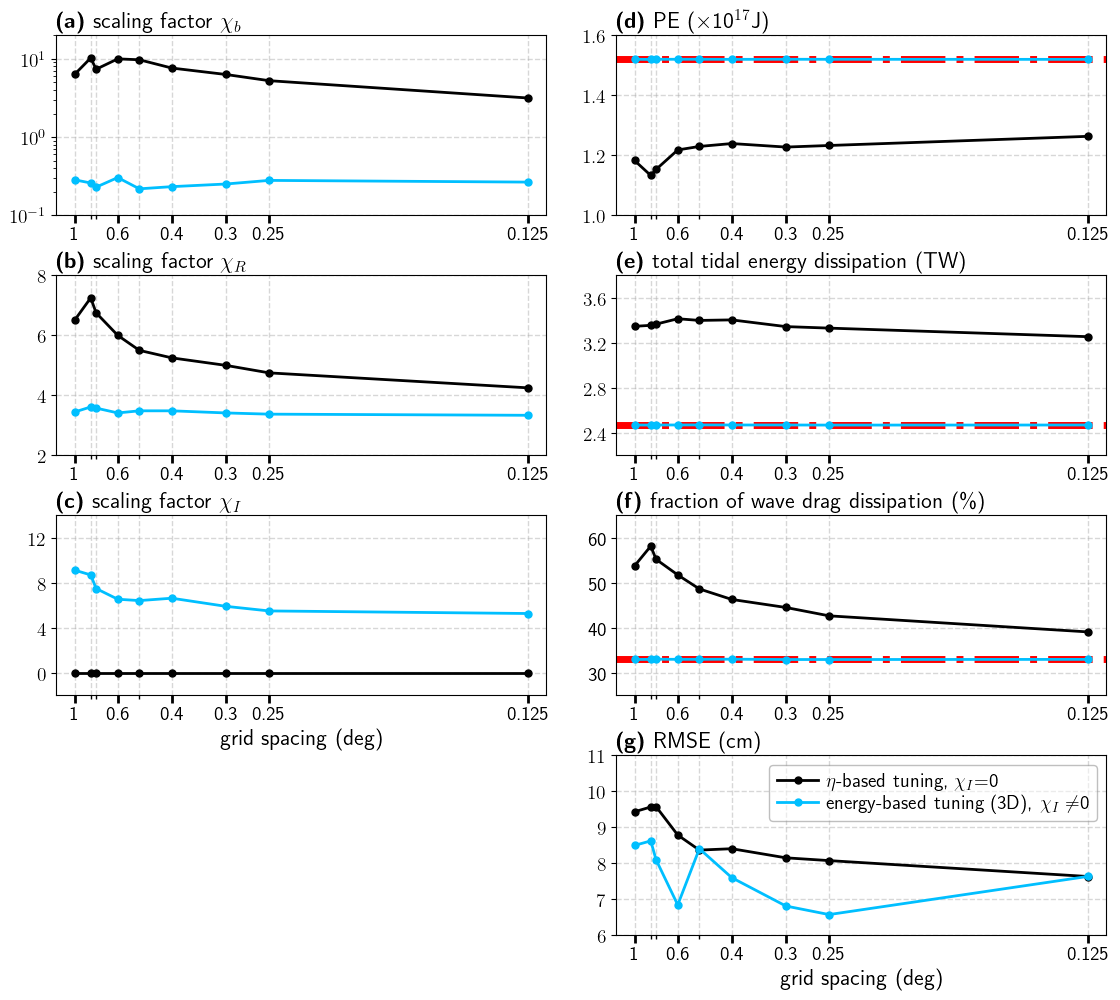

In [11]:
# Enable LaTeX text rendering
plt.rc('text', usetex=True)

fig = plt.figure(figsize=(14, 12))
axs = []

gridsubs = gridspec.GridSpec(4,2)
for gs in gridsubs:
    axs.append(plt.subplot(gs))

ms = 5
# res = np.array([1,00, 0.90, 0.80, 0.75, 0.60, 0.50, 0.40, 0.25, 0.125])
res = np.array([1,00, 0.80, 0.75, 0.60, 0.50, 0.40, 0.30, 0.25, 0.125])

for I, ax in enumerate(axs):
    
    ax.set_xlim(130,1490)
    ax.set_xticks(grid)
    # ax.set_xticklabels(['2.00','1.50','1.25','','1.00','0.90','','0.75'])
    ax.set_xticklabels(['1','','','0.6','','0.4','0.3','0.25','0.125'])
    ax.tick_params(labelsize=14)

    for tick, label in zip(ax.xaxis.get_major_ticks(), ax.get_xticklabels()):
        if label.get_text():  # non-empty label
            tick.tick1line.set_markersize(6)
            tick.tick1line.set_markeredgewidth(2)
            tick.tick2line.set_markersize(6)
            tick.tick2line.set_markeredgewidth(2)
        else:
            tick.tick1line.set_markersize(3)
            tick.tick1line.set_markeredgewidth(1)
            tick.tick2line.set_markersize(3)
            tick.tick2line.set_markeredgewidth(1)

    if I==0:
        ax.plot(grid[:],cd_scal[2,:]/np.sqrt(1000)/3e-5,'-o',color='k',linewidth=2,markersize=ms,label=r'$\eta$-based tuning, $\chi_I$=0')
        ax.plot(grid[:],cd_scal[4,:]/np.sqrt(1000)/3e-5,'-o',color='deepskyblue',linewidth=2,markersize=ms,label=r'energy-based tuning (3D), $\chi_I\neq$0')
        ax.grid(True, alpha=0.5, linestyle='--', linewidth=1)
        ax.set_ylim(1e-1,20)
        # ax.set_yticks(np.arange(0,12+4,4))
        ax.set_yscale('log')
        ax.yaxis.set_major_locator(LogLocator(base=10.0))
        # ax.set_yticklabels(['0','4','8','12','16'])
        ax.set_title(r'\textbf{(a)} scaling factor $\chi_b$',fontsize=16,loc='left')
        ax.set_position([0.1,0.7,0.35,0.15])

    if I==1:
        # ax.plot(grid,wd_scal[0,:],'-o',color='k',linewidth=4,alpha=0.5,markersize=ms,label='old')
        # ax.plot(grid,wd_scal[1,:],'-o',color='k',linewidth=2,alpha=0.5,markersize=ms)
        ax.plot(grid[:],wd_scal[2,:],'-o',color='k',linewidth=2,markersize=ms)
        ax.plot(grid[:],wd_scal[4,:],'-o',color='deepskyblue',linewidth=2,markersize=ms)
        # ax.plot(grid,wd_scal[3,:],'--o',color='r',linewidth=2,markersize=ms,label='new, op=0')
        ax.grid(True, alpha=0.5, linestyle='--', linewidth=1)
        ax.set_ylim(2,8)
        ax.set_yticks(np.arange(2,8+2,2))
        ax.set_title(r'\textbf{(b)} scaling factor $\chi_R$',fontsize=16,loc='left')
        ax.set_position([0.1,0.5,0.35,0.15])

    if I==2:
        # ax.plot(grid,op_scal[0,:],'-o',color='k',linewidth=4,alpha=0.5,markersize=ms,label='old')
        # ax.plot(grid,op_scal[1,:],'-o',color='k',linewidth=2,alpha=0.5,markersize=ms)
        ax.plot(grid[:],op_scal[2,:],'-o',color='k',linewidth=2,markersize=ms)
        ax.plot(grid[:],op_scal[4,:],'-o',color='deepskyblue',linewidth=2,markersize=ms)
        # ax.plot(grid,op_scal[3,:],'--o',color='r',linewidth=2,markersize=ms,label='new, op=0')
        # ax.scatter(grid[1], 10, marker='o', facecolors='none', edgecolors='b', s=120, linewidths=2)
        ax.grid(True, alpha=0.5, linestyle='--', linewidth=1)
        ax.set_ylim(-2,14)
        ax.set_yticks(np.arange(-0,12+4,4))
        ax.set_title(r'\textbf{(c)} scaling factor $\chi_I$',fontsize=16,loc='left')
        ax.set_xlabel('grid spacing (deg)',fontsize=16)
        ax.set_position([0.1,0.3,0.35,0.15])

    if I==3:
        # ax.plot(grid,ener[0,:],'-o',color='k',linewidth=4,alpha=0.5,markersize=ms,label='old')
        ax.hlines(y=pe1, xmin=100, xmax=1500, color='red', linewidth=5,linestyle='-.')
        # ax.plot(grid,pe[1,:],'-o',color='k',linewidth=2,alpha=0.5,markersize=ms)
        ax.plot(grid[:],pe[2,:],'-o',color='k',linewidth=2,markersize=ms)
        ax.plot(grid[:],pe[4,:],'-o',color='deepskyblue',linewidth=2,markersize=ms)
        
        # ax.plot(grid,ener[3,:],'--o',color='r',linewidth=2,markersize=ms,label='new, op=0')
        ax.grid(True, alpha=0.5, linestyle='--', linewidth=1)
        ax.set_ylim(1.0,1.6)
        ax.set_yticks(np.array([1.0,1.2,1.4,1.6]))
        
        ax.set_title(r'\textbf{(d)} PE ($\times$10$^{17}$J)',fontsize=16,loc='left')
            
        ax.set_position([0.5,0.7,0.35,0.15])
        
    if I==4:
        ax.hlines(y=ef1, xmin=100, xmax=1500, color='red', linewidth=5,linestyle='-.')
        # ax.plot(grid,ener[1,:],'-o',color='k',linewidth=2,alpha=0.5,markersize=ms)
        ax.plot(grid[:],ener[2,:],'-o',color='k',linewidth=2,markersize=ms)
        ax.plot(grid[:],ener[4,:],'-o',color='deepskyblue',linewidth=2,markersize=ms)
        # ax.plot(grid,frac[3,:],'--o',color='r',linewidth=2,markersize=ms,label='new, op=0')
        ax.grid(True, alpha=0.5, linestyle='--', linewidth=1)
        ax.set_ylim(2.2,3.8)
        ax.set_yticks(np.array([2.4,2.8,3.2,3.6]))
        
        ax.set_title(r'\textbf{(e)} total tidal energy dissipation (TW)',fontsize=16,loc='left')
        
        ax.set_position([0.5,0.5,0.35,0.15])

    if I==5:
        # ax.plot(grid,pe[0,:],'-o',color='k',linewidth=4,alpha=0.5,markersize=ms,label='old')
        ax.hlines(y=frac1, xmin=100, xmax=1500, color='red', linewidth=5,linestyle='-.')
        # ax.plot(grid,frac[1,:],'-o',color='k',linewidth=2,alpha=0.5,markersize=ms)
        ax.plot(grid[:],frac[2,:],'-o',color='k',linewidth=2,markersize=ms)
        ax.plot(grid[:],frac[4,:],'-o',color='deepskyblue',linewidth=2,markersize=ms)        
        # ax.plot(grid,pe[3,:],'--o',color='r',linewidth=2,markersize=ms,label='new, op=0')
        ax.grid(True, alpha=0.5, linestyle='--', linewidth=1)
        ax.set_ylim(0.25,0.65)
        ax.set_yticks(np.array([0.30,0.40,0.50,0.60]))
        ax.set_yticklabels(['30','40','50','60'])
        ax.set_title(r'\textbf{(f)} fraction of wave drag dissipation (\%)',fontsize=16,loc='left')
        ax.set_position([0.5,0.3,0.35,0.15])

    if I==6:
        ax.axis("off")

    if I==7:
        # ax.plot(grid,rmse[1,:],'-o',color='k',linewidth=2,alpha=0.5,markersize=ms)
        ax.plot(grid[:],rmse[2,:],'-o',color='k',linewidth=2,markersize=ms,label=r'$\eta$-based tuning, $\chi_I$=0')
        ax.plot(grid[:],rmse[4,:],'-o',color='deepskyblue',linewidth=2,markersize=ms,label=r'energy-based tuning (3D), $\chi_I\neq$0') 
        leg = ax.legend(loc=1,handlelength=2.1,handletextpad=0.4,fontsize=14,labelspacing=0.2,frameon=True,ncol=1)
        leg.get_frame().set_facecolor('white')  # background color
        leg.get_frame().set_alpha(0.5) 
        leg.get_frame().set_edgecolor('gray')
        ax.grid(True, alpha=0.5, linestyle='--', linewidth=1)
        ax.set_ylim(6,11)
        ax.set_yticks(np.array([6,7,8,9,10,11]))
        ax.set_title(r'\textbf{(g)} RMSE (cm)',fontsize=16,loc='left')
        ax.set_xlabel('grid spacing (deg)',fontsize=16)
        ax.set_position([0.5,0.1,0.35,0.15])

# plt.savefig('/g/data/nm03/lxy581/matlab_model/figures/sens_res_M2_3D_2000m_synbath.png', dpi=300, bbox_inches='tight')
plt.savefig('/g/data/nm03/lxy581/matlab_model/figures/sens_res_M2_3D_1000m_synbath_interp.png', dpi=300, bbox_inches='tight')
# plt.savefig('/g/data/nm03/lxy581/matlab_model/figures/sens_res_M2_3D_1000m_synbath_interp_low_res.png', dpi=300, bbox_inches='tight')